## 1. Import Library

In [45]:
# pandas, manipulasi data tabel
import pandas as pd
#operasi matematis
import numpy as np
# matplotlib, visualisasi grafik
import matplotlib.pyplot as plt
# sklearn, semua keperluan machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
# Counter, menghitung frekuensi item
from collections import Counter
# joblib , menyimpan model
import joblib
# warnings, menyembunyikan pesan peringatan yang tidak penting
import warnings
warnings.filterwarnings('ignore')

## 2. Load dan Eksplorasi Dataset

In [21]:
df = pd.read_csv("rym.csv")
df.head()

,position,release_name,artist_name,release_date,release_type,primary_genres,secondary_genres,descriptors,avg_rating,rating_count,review_count,spotify_search_url,accessibility
0,1,OK Computer,Radiohead,1997-06-16,album,"Alternative Rock, Art Rock",NaN,"melancholic, anxious, futuristic, malevocals, ...",4.24,74027,1541,https://open.spotify.com/search/album%3A%22OK%...,6.0
1,2,Kid A,Radiohead,2000-10-03,album,"Art Rock, Experimental Rock, Electronic","Ambient, Electronic, IDM","cold, melancholic, futuristic, anxious, atmosp...",4.23,61658,751,https://open.spotify.com/search/album%3A%22Kid...,3.4
2,3,The Dark Side of the Moon,Pink Floyd,1973-03-23,album,"Art Rock, Progressive Rock","Psychedelic Rock, Space Rock","philosophical, atmospheric, introspective, exi...",4.21,60192,1557,https://open.spotify.com/search/album%3A%22The...,5.3
3,4,Loveless,My Bloody Valentine,1991-11-11,album,"Shoegaze, Noise Pop","Dream Pop, Neo-Psychedelia","noisy, ethereal, atmospheric, romantic, love, ...",4.24,53174,1264,https://open.spotify.com/search/album%3A%22Lov...,5.0
4,5,My Beautiful Dark Twisted Fantasy,Kanye West,2010-11-22,album,"Pop Rap, Hip Hop",Art Pop,"epic, boastful, passionate, sampling, hedonist...",4.09,52149,638,https://open.spotify.com/search/album%3A%22My%...,8.4


In [32]:
df.shape

(5000, 13)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   position            5000 non-null   int64  
 1   release_name        5000 non-null   object 
 2   artist_name         5000 non-null   object 
 3   release_date        5000 non-null   object 
 4   release_type        5000 non-null   object 
 5   primary_genres      4999 non-null   object 
 6   secondary_genres    4505 non-null   object 
 7   descriptors         5000 non-null   object 
 8   avg_rating          5000 non-null   float64
 9   rating_count        5000 non-null   int64  
 10  review_count        5000 non-null   int64  
 11  spotify_search_url  5000 non-null   object 
 12  accessibility       5000 non-null   float64
dtypes: float64(2), int64(3), object(8)
memory usage: 507.9+ KB


In [43]:
df.describe()

,position,avg_rating,rating_count,review_count,accessibility,year,log_rating_count,log_review_count
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,3.540424,6083.700800,101.30200,5.914320,1997.449400,8.458637,4.313340
std,1443.520003,0.374449,5899.645056,106.48523,2.299018,16.644953,0.640872,0.759999
min,1.000000,0.620000,2169.000000,6.00000,1.000000,1954.000000,7.682482,1.945910
25%,1250.750000,3.410000,2830.000000,44.00000,4.400000,1984.000000,7.948385,3.806662
50%,2500.500000,3.620000,3973.000000,72.00000,6.200000,2000.000000,8.287528,4.290459
75%,3750.250000,3.770000,6736.750000,117.00000,7.600000,2012.000000,8.815481,4.770685
max,5000.000000,4.340000,74027.000000,1557.00000,10.000000,2022.000000,11.212199,7.351158


In [35]:
df.isna().sum()

position                0
release_name            0
artist_name             0
release_date            0
release_type            0
primary_genres          1
secondary_genres      495
descriptors             0
avg_rating              0
rating_count            0
review_count            0
spotify_search_url      0
accessibility           0
dtype: int64

## 3. Feature Engineering — Membuat Label Era & Aksesibilitas

In [22]:
# FEATURE ENGINEERING: Membuat fitur baru dari data yang ada

# Ambil tahun dari tanggal rilis
df['year'] = pd.to_datetime(df['release_date']).dt.year

# Transformasi log untuk fitur numerik yang skewnya tinggi
df['log_rating_count'] = np.log1p(df['rating_count'])
df['log_review_count']  = np.log1p(df['review_count'])

# Label Era
ERA_BINS   = [0, 1969, 1984, 1999, 2012, 2026]
ERA_LABELS = ['Pionir', 'Old School', 'Mid High School', 'New School', 'New New School']
df['era'] = pd.cut(df['year'], bins=ERA_BINS, labels=ERA_LABELS)

# Label Aksesibilitas
ACC_BINS   = [0, 2, 4, 6, 8, 10.1]
ACC_LABELS = ['Niche', 'Elitis', 'Tidak Basic', 'Agak Lumayan Basic', 'Basic']
df['acc_label'] = pd.cut(df['accessibility'], bins=ACC_BINS, labels=ACC_LABELS)

# Hapus baris dengan NaN pada kolom label
df = df.dropna(subset=['era', 'acc_label'])

#liat jumlah data ditiap kategori
print(df['era'].value_counts().sort_index())
print(df['acc_label'].value_counts())

era
Pionir              317
Old School          947
Mid High School    1167
New School         1392
New New School     1177
Name: count, dtype: int64
acc_label
Agak Lumayan Basic    1692
Tidak Basic           1318
Basic                  904
Elitis                 720
Niche                  366
Name: count, dtype: int64


In [23]:
print("Distribusi Era:")
#hitung era dan urutkan berdasarkan urutan label
print(df['era'].value_counts().sort_index())
print()
print("Distribusi Aksesibilitas:")
print(df['acc_label'].value_counts())

Distribusi Era:
era
Pionir              317
Old School          947
Mid High School    1167
New School         1392
New New School     1177
Name: count, dtype: int64

Distribusi Aksesibilitas:
acc_label
Agak Lumayan Basic    1692
Tidak Basic           1318
Basic                  904
Elitis                 720
Niche                  366
Name: count, dtype: int64


## 4. Visualisasi Distribusi

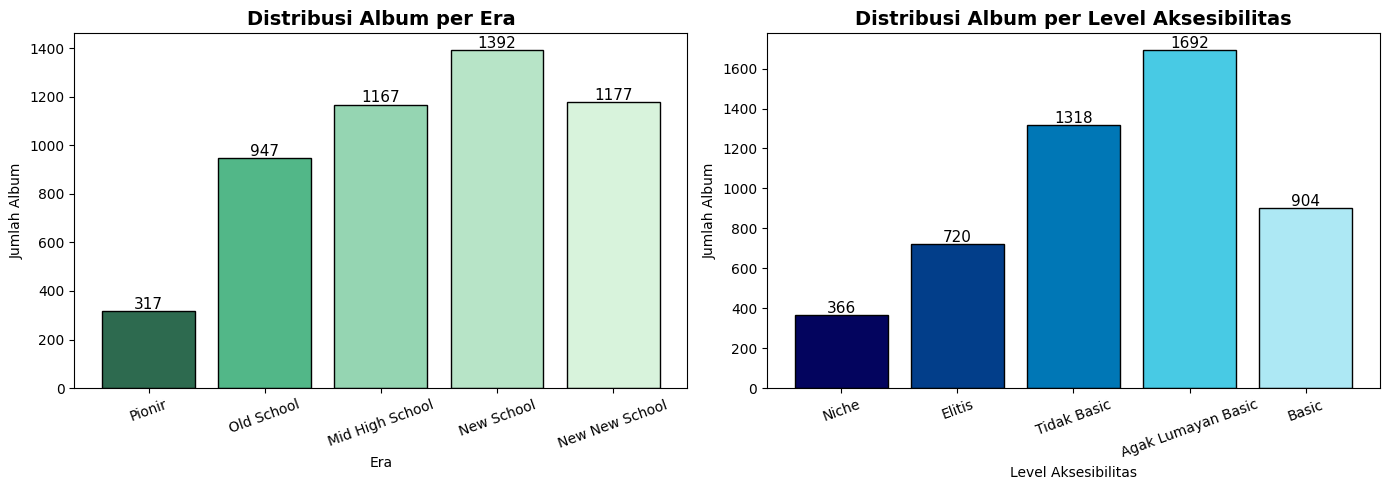

In [24]:
# Visualisasi distribusi era dan aksesibilitas mdengan bar chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi Era
era_counts = df['era'].value_counts().sort_index()
axes[0].bar(era_counts.index, era_counts.values, color=['#2d6a4f','#52b788','#95d5b2','#b7e4c7','#d8f3dc'], edgecolor='black')
axes[0].set_title('Distribusi Album per Era', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Era')
axes[0].set_ylabel('Jumlah Album')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(era_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=11)

# Distribusi Aksesibilitas

#urutab
acc_order = ['Niche', 'Elitis', 'Tidak Basic', 'Agak Lumayan Basic', 'Basic']
acc_counts = df['acc_label'].value_counts().reindex(acc_order)
#mengatur bar chart
axes[1].bar(acc_counts.index, acc_counts.values, color=['#03045e','#023e8a','#0077b6','#48cae4','#ade8f4'], edgecolor='black')
axes[1].set_title('Distribusi Album per Level Aksesibilitas', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Level Aksesibilitas')
axes[1].set_ylabel('Jumlah Album')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(acc_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Model 1: Klasifikasi Era
untuk prediksi era

Fitur yang digunakan: `year`, `avg_rating`, `log_rating_count`, `log_review_count`, `accessibility`

In [25]:
#persiapan data
# X/fiturnya, year, rata2 rating, log jumlah penilai, log jumlah reiewer, skor aksesibilitas
# y/target, era

#memisah data latihan dan data tes
X_era = df[['year', 'avg_rating', 'log_rating_count', 'log_review_count', 'accessibility']]
y_era = df['era']

X_era_train, X_era_test, y_era_train, y_era_test = train_test_split(
    X_era, y_era, test_size=0.2, random_state=42
)

In [26]:
# melatih 3 model dan bandingkan akurasi
#   pipeline untuk membugkus model, StandardScaler, normalisasi fitur
era_models = { 
# Model 1 – Logistic Regression:
#   cepat dan mudah diinterpretasikan.
#   max_iter=1000 supaya konvergen pada dataset yang lebih besar.
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    
# Model 2 – Random Forest:
#   Ensemble dari banyak Decision Tree. Sangat kuat untuk data tabular.
#   n_estimators=100, membangun 100 pohon keputusan.
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    
# Model 3 – K-Nearest Neighbors (KNN):
#   Algoritma berbasis jarak, prediksi berdasarkan 5 tetangga terdekat.
#   n_neighbors=5, melihat 5 album paling mirip untuk menentukan era.
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
}

print("        HASIL PERBANDINGAN ERA MODEL")

hasil_era = {}
for nama, model in era_models.items():
    # Latih model
    model.fit(X_era_train, y_era_train)
    # Prediksi pada data uji
    y_pred = model.predict(X_era_test)
    # Hitung akurasi
    akurasi = accuracy_score(y_era_test, y_pred)
    hasil_era[nama] = akurasi
    print(f"  {nama:25s} → Akurasi: {akurasi*100:.2f}%")

#model yang terbaik dianu jadi bisa dipanggil nanti jika diperlukan
model_era_gacor = max(hasil_era, key=hasil_era.get)

        HASIL PERBANDINGAN ERA MODEL
  Logistic Regression       → Akurasi: 96.50%
  Random Forest             → Akurasi: 100.00%
  KNN                       → Akurasi: 88.30%


In [27]:
#tes akurasi
model_era_gacor = era_models[model_era_gacor]
y_pred_era = model_era_gacor.predict(X_era_test)

#perlihatkan hasil
print(f"Classification Report – {model_era_gacor} (Era Model)")
print("-" * 55)
print(classification_report(y_era_test, y_pred_era))

Classification Report – Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))]) (Era Model)
-------------------------------------------------------
                 precision    recall  f1-score   support

Mid High School       1.00      1.00      1.00       247
 New New School       1.00      1.00      1.00       221
     New School       1.00      1.00      1.00       264
     Old School       1.00      1.00      1.00       190
         Pionir       1.00      1.00      1.00        78

       accuracy                           1.00      1000
      macro avg       1.00      1.00      1.00      1000
   weighted avg       1.00      1.00      1.00      1000



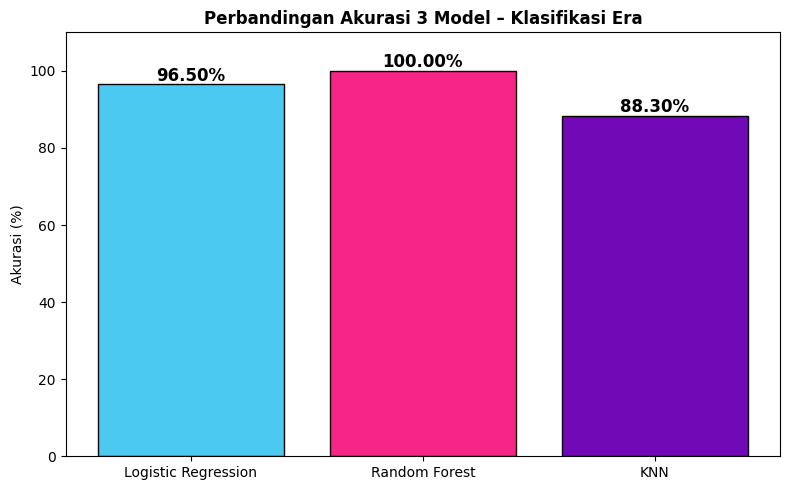

In [28]:
# Perbandingan akurasi 3 model era dalam bentuk bar chart

plt.figure(figsize=(8, 5))
bars = plt.bar(hasil_era.keys(), [v * 100 for v in hasil_era.values()],
               color=['#4cc9f0', '#f72585', '#7209b7'], edgecolor='black')
plt.ylim(0, 110)
plt.ylabel('Akurasi (%)')
plt.title('Perbandingan Akurasi 3 Model – Klasifikasi Era', fontweight='bold')
for bar, val in zip(bars, hasil_era.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{val*100:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
#simpan menjadi file joblib
joblib.dump(model_era_gacor, "model_era_gacor.joblib")

['model_era_gacor.joblib']

## 6. Model 2: Klasifikasi Aksesibilitas
**Tujuan:** Memprediksi level aksesibilitas album
kodenya hampir sama dengan model era

Fitur yang digunakan: `accessibility`, `avg_rating`, `log_rating_count`, `log_review_count`

In [30]:
X_acc = df[['accessibility', 'avg_rating', 'log_rating_count', 'log_review_count']]
y_acc = df['acc_label']

X_acc_train, X_acc_test, y_acc_train, y_acc_test = train_test_split(
    X_acc, y_acc, test_size=0.2, random_state=42
)

In [31]:
acc_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
}



hasil_acc = {}
for nama, model in acc_models.items():
    model.fit(X_acc_train, y_acc_train)
    y_pred = model.predict(X_acc_test)
    akurasi = accuracy_score(y_acc_test, y_pred)
    hasil_acc[nama] = akurasi
    print(f"  {nama:25s} Akurasi: {akurasi*100:.2f}%")
    
model_acc_gacor = max(hasil_acc, key=hasil_acc.get)

  Logistic Regression       Akurasi: 98.00%
  Random Forest             Akurasi: 100.00%
  KNN                       Akurasi: 91.20%


  Random Forest             → Akurasi: 100.00%
  KNN                       → Akurasi: 91.20%
  🏆 Model terbaik: Random Forest


In [32]:
#laporan model terbaik
model_acc_gacor = acc_models[model_acc_gacor]
y_pred_acc =model_acc_gacor.predict(X_acc_test)

print(f"Classification Report – {model_acc_gacor} (Aksesibilitas Model)")
print("-" * 58)
print(classification_report(y_acc_test, y_pred_acc))

Classification Report – Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))]) (Aksesibilitas Model)
----------------------------------------------------------
                    precision    recall  f1-score   support

Agak Lumayan Basic       1.00      1.00      1.00       319
             Basic       1.00      1.00      1.00       187
            Elitis       1.00      1.00      1.00       146
             Niche       1.00      1.00      1.00        84
       Tidak Basic       1.00      1.00      1.00       264

          accuracy                           1.00      1000
         macro avg       1.00      1.00      1.00      1000
      weighted avg       1.00      1.00      1.00      1000



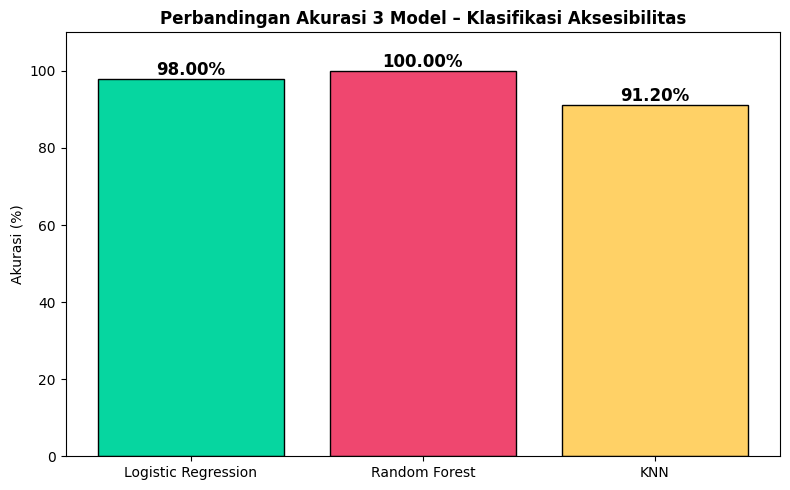

In [33]:
#perbandingan dengan bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(hasil_acc.keys(), [v * 100 for v in hasil_acc.values()],
               color=['#06d6a0', '#ef476f', '#ffd166'], edgecolor='black')
plt.ylim(0, 110)
plt.ylabel('Akurasi (%)')
plt.title('Perbandingan Akurasi 3 Model – Klasifikasi Aksesibilitas', fontweight='bold')
for bar, val in zip(bars, hasil_acc.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{val*100:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [89]:
#simpan menjadi joblib
joblib.dump(model_acc_gacor, "model_acc_gacor.joblib")

['model_acc_gacor.joblib']

## 7. Fungsi-Fungsi Utama Pipeline

In [34]:
# FUNGSI 1: cari_album_di_dataset
# Menerima list album+artis dari pengguna, lalu mencari
# kecocokan di dataset RYM secara case-insensitive.
# Cara kerja:, Input diubah ke huruf kecil, Setiap baris dataset dicek: apakah nama album DAN artis,
#mengandung kata kunci yang dimasukkan?, Mengembalikan DataFrame baris-baris yang cocok
# Parameter:
#   input_list, list of dict, setiap dict punya key album dan artis
#   dataset, DataFrame RYM yang sudah diproses

def cari_album_di_dataset(input_list, dataset):
    hasil = []
    for item in input_list:
        nama_album = item['album'].lower().strip()
        nama_artis  = item['artis'].lower().strip()
        # Cari baris yang nama albumnya mengandung kata kunci
        cocok = dataset[
            dataset['release_name'].str.lower().str.contains(nama_album, na=False) &
            dataset['artist_name'].str.lower().str.contains(nama_artis, na=False)
        ]
        # Jika ketemu, ambil baris pertama (paling relevan)
        if not cocok.empty:
            hasil.append(cocok.iloc[0])
    
    if not hasil:
        return pd.DataFrame()
    return pd.DataFrame(hasil)

In [44]:
# FUNGSI 2: prediksi_era_pengguna
# Dari album-album yang ditemukan di dataset, gunakan model ERA
# untuk memprediksi era setiap album, lalu tentukan era yang
# paling sering muncul = era favorit pengguna.
# Cara kerja:, Ambil fitur dari setiap album yang ditemukan, Minta model era memprediksi era album tersebut,
#Counter untuk menghitung era mana yang paling dominan, Jika seri, ambil era yang rata-rata ratingnya lebih tinggi

ERA_KETERANGAN = {
    'Pionir': {
        'rentang'    : '~1920 - 1969',
        'keterangan' : 'Era perintis musik rekaman modern. Musik zaman ini merupakan fondasi dari semua yang kita dengar sekarang. Ditandai oleh lahirnya rock n roll, soul klasik, jazz besar, folk awal, dan eksperimen psikedelik pertama. Tokoh seperti The Beatles, Bob Dylan, Jimi Hendrix, Miles Davis, dan Motown mendefinisikan apa artinya bermusik. Kamu punya selera klasik yang mendalam dan menghargai akar dari segala genre modern.'
    },
    'Old School': {
        'rentang'    : '1970 - 1984',
        'keterangan' : 'Era rock klasik, prog, punk, funk, soul, dan disco. Ini masa kejayaan album sebagai medium utama bermusik — orang beli vinyl dan dengar dari depan sampai belakang. Led Zeppelin, Pink Floyd, Black Sabbath, Fleetwood Mac, Stevie Wonder, The Clash mendominasi. Kamu menikmati musik yang terasa besar, epik, dan penuh craftsmanship.'
    },
    'Mid High School': {
        'rentang'    : '1985 - 1999',
        'keterangan' : 'Era alternatif, grunge, shoegaze, hip-hop golden age, britpop, dan elektronik awal. MTV mengubah cara orang mengonsumsi musik. Nirvana, Radiohead, Massive Attack, Nas, Bjork, My Bloody Valentine menjadi ikon. Musik terasa raw, penuh emosi, dan subversif. Kamu suka musik yang berkarakter kuat dan tidak mainstream.'
    },
    'New School': {
        'rentang'    : '2000 - 2012',
        'keterangan' : 'Era indie boom, emo, post-rock, digital revolution, dan hip-hop modern. iTunes dan MySpace mengubah distribusi musik. Arcade Fire, Radiohead (lagi), Kanye West, LCD Soundsystem, Bon Iver, Sufjan Stevens mendefinisikan dekade ini. Kamu menikmati musik yang thoughtful, layered, dan seringkali punya narasi kuat.'
    },
    'New New School': {
        'rentang'    : '2013 - sekarang',
        'keterangan' : 'Era streaming, SoundCloud rap, hyperpop, bedroom pop, dan genre-blending tanpa batas. Spotify dan Apple Music mendominasi konsumsi musik. Kendrick Lamar, Frank Ocean, Lorde, The Weeknd, Billie Eilish, Rosalia, dan ribuan artis DIY bermunculan. Kamu mengikuti perkembangan musik kontemporer dan tidak takut mengeksplorasi sound yang tidak konvensional.'
    }
}

def prediksi_era_pengguna(df_album_cocok, model_era):
    fitur = df_album_cocok[['year', 'avg_rating', 'log_rating_count', 'log_review_count', 'accessibility']]
    prediksi = model_era.predict(fitur)
    # Hitung era yang paling sering muncul
    era_dominan = Counter(prediksi).most_common(1)[0][0]
    return era_dominan, prediksi

In [43]:
# FUNGSI 3: prediksi_aksesibilitas_pengguna
# Dari album yang ditemukan, prediksi level aksesibilitas tiap album
# lalu cari yang paling dominan = selera aksesibilitas pengguna.

ACC_KETERANGAN = {
    'Niche': {
        'emoji'      : '🔬',
        'keterangan' : 'Selera kamu sangat niche, bisa dipastikan tidak pernah diberi akses speaker. jarang mandi.'
    },
    'Elitis': {
        'emoji'      : '🎓',
        'keterangan' : 'Selera kamu elitis, bisa dipastikan jarang diberi akses speaker.'
    },
    'Tidak Basic': {
        'emoji'      : '🎸',
        'keterangan' : 'Selera kamu tidak basic, berpendirian dan berpendidikan dan punya kemampuan bersosialisasi.'
    },
    'Agak Lumayan Basic': {
        'emoji'      : '🎧',
        'keterangan' : 'selerammu agak lumayan basic, ehh, bolelahbolelah.'
    },
    'Basic': {
        'emoji'      : '📻',
        'keterangan' : 'selera kamu mainstream yang berarti kamu orangnya basic dan minim literasi, FOMO dan rambutnya modelan dirapiin dikit aja pak.'
    }
}

def prediksi_aksesibilitas_pengguna(df_album_cocok, model_acc):
    fitur = df_album_cocok[['accessibility', 'avg_rating', 'log_rating_count', 'log_review_count']]
    prediksi = model_acc.predict(fitur)
    acc_dominan = Counter(prediksi).most_common(1)[0][0]
    return acc_dominan, prediksi


In [41]:
# FUNGSI 4: analisis_mood
# Menganalisis deskriptor dari semua album yang ditemukan lalu mengembalikan 3 mood teratas.
# Cara kerja:
# Pisahkan setiap string descriptor menjadi list kata, Kumpulkan semua kata dari semua album ke satu list besar
#Gunakan Counter untuk menghitung frekuensi masing-masing, Kembalikan 3 yang paling sering muncul

# Beberapa kata di-exclude karena bersifat teknis
EXCLUDE_DESCRIPTOR = {'malevocals', 'femalevocals', 'conceptalbum', 'instrumental'}

def analisis_mood(df_album_cocok):
    semua_descriptor = []
    for desc_str in df_album_cocok['descriptors'].dropna():
        kata_kata = [k.strip() for k in desc_str.split(',')]
        kata_kata = [k for k in kata_kata if k not in EXCLUDE_DESCRIPTOR]
        semua_descriptor.extend(kata_kata)
    
    if not semua_descriptor:
        return [('tidak tersedia', 0)]
    
    top3 = Counter(semua_descriptor).most_common(3)
    return top3

In [38]:
# FUNGSI 5: rekomendasikan_album
# Merekomendasikan 5 album dari dataset yang kemungkinan disukai
# pengguna, berdasarkan: Era yang sama dengan era favorit pengguna, Level aksesibilitas yang sama atau berdekatan, Descriptor yang paling banyak overlap dengan selera
# Cara kerja : Filter dataset berdasarkan era favorit, yang cocok dengan top mood pengguna dll

ACC_ORDER = ['Niche', 'Elitis', 'Tidak Basic', 'Agak Lumayan Basic', 'Basic']

def rekomendasikan_album(era_favorit, acc_favorit, top_mood, df_album_cocok, dataset):
    # Kumpulkan nama album yang sudah disukai (untuk exclude)
    nama_sudah_suka = set(df_album_cocok['release_name'].str.lower())
    
    # cari yang nilai aksesibilitasnya mirip degan sipengguna
    acc_idx = ACC_ORDER.index(acc_favorit) if acc_favorit in ACC_ORDER else 2
    acc_range_idx = list(set([max(0, acc_idx - 1), acc_idx, min(4, acc_idx + 1)]))
    acc_range = [ACC_ORDER[i] for i in acc_range_idx]
    
    # Kumpulkan kata mood teratas pengguna
    kata_mood = set([m[0] for m in top_mood])
    
    # Filter berdasarkan era dan aksesibilitas
    kandidat = dataset[
        (dataset['era'] == era_favorit) &
        (dataset['acc_label'].isin(acc_range)) &
        (~dataset['release_name'].str.lower().isin(nama_sudah_suka))
    ].copy()
    
    # Jika terlalu sedikit kandidat, buka ke semua aksesibilitas era yang sama
    if len(kandidat) < 5:
        kandidat = dataset[
            (dataset['era'] == era_favorit) &
            (~dataset['release_name'].str.lower().isin(nama_sudah_suka))
        ].copy()
    
    # Hitung skor mood yang sama dengan sipengguna
    def hitung_skor_mood(desc_str):
        if pd.isna(desc_str):
            return 0
        kata = set([k.strip() for k in desc_str.split(',')])
        return len(kata & kata_mood)
    
    kandidat['skor_mood'] = kandidat['descriptors'].apply(hitung_skor_mood)
    
    # Urutkan: prioritas skor mood, lalu avg_rating
    kandidat = kandidat.sort_values(
        by=['skor_mood', 'avg_rating'], ascending=[False, False]
    )
    
    # Pilih kolom yang ditampilkan
    kolom_tampil = ['release_name', 'artist_name', 'year', 'primary_genres',
                    'avg_rating', 'acc_label', 'spotify_search_url']
    
    return kandidat[kolom_tampil].head(5)

✅ Fungsi rekomendasikan_album siap!
